In [1]:
import numpy as np
import pandas as pd

In [2]:
n_samples = 6000

uniform_data = 100 * np.random.rand(n_samples)
skewed_data = 100 * np.random.beta(a=2, b=5, size=n_samples)
clustered_data = np.concat([
    3.0 + 0.5 * np.random.randn(int(n_samples/3)),
    9.0 + 1.5 * np.random.randn(int(n_samples/3)),
    15.0 + 0.5 * np.random.randn(int(n_samples/3))
])

data = pd.DataFrame({
    'U' : uniform_data,
    'S' : skewed_data,
    'C' : clustered_data
})

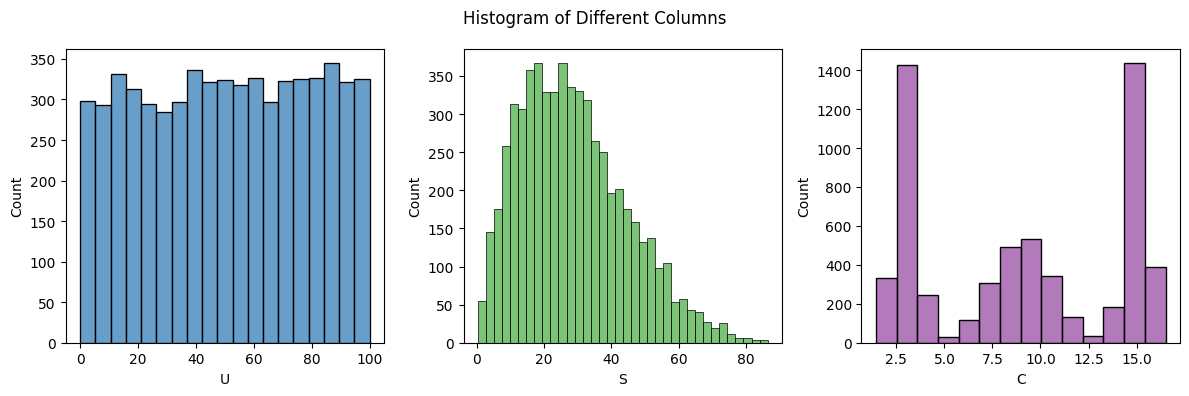

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 4))

for idx, col in enumerate(data.columns):
    plt.subplot(1, len(data.columns), idx+1)
    sns.histplot(x=data[col], color=sns.color_palette('Set1')[idx+1])
    plt.xlabel(f'{col}')
    plt.ylabel('Count')
plt.suptitle('Histogram of Different Columns')
plt.tight_layout()
plt.show()

### **General Guideline**
- Uniform distributions: Equal width binning
- Normal distribution: Z-score-based binning
- Skewed distributions: Equal frequency binning 
- Natural clusters: Clustering-based binning

In [4]:
n_bins = 4
labels = [str(x) for x in range(1, n_bins+1)]

data['U_bin_uniform'] = pd.cut(data['U'], bins=n_bins, labels=labels)
data

,U,S,C,U_bin_uniform
0,63.377313,28.318881,2.627667,3
1,18.256564,8.424288,2.045288,1
2,45.220850,25.973508,2.625433,2
3,51.775917,30.470380,2.767951,3
4,62.799528,48.577210,3.397070,3
...,...,...,...,...
5995,8.391266,23.884147,14.697057,1
5996,95.583228,10.622332,14.843714,4
5997,7.601345,60.046105,14.139877,1
5998,95.851275,12.621418,13.494020,4


In [5]:
data['S_bin_quantile'] = pd.qcut(data['S'], q=n_bins, labels=labels)
data

,U,S,C,U_bin_uniform,S_bin_quantile
0,63.377313,28.318881,2.627667,3,3
1,18.256564,8.424288,2.045288,1,1
2,45.220850,25.973508,2.625433,2,2
3,51.775917,30.470380,2.767951,3,3
4,62.799528,48.577210,3.397070,3,4
...,...,...,...,...,...
5995,8.391266,23.884147,14.697057,1,2
5996,95.583228,10.622332,14.843714,4,1
5997,7.601345,60.046105,14.139877,1,4
5998,95.851275,12.621418,13.494020,4,1


In [6]:
data['S_bin_uniform'] = pd.cut(data['S'], bins=n_bins, labels=labels)

comparison_df = pd.concat([
    data[['S', 'S_bin_quantile']].groupby('S_bin_quantile', observed=True).std().rename(columns={'S' : 'Quantile'}),
    data[['S', 'S_bin_uniform']].groupby('S_bin_uniform', observed=True).std().rename(columns={'S' : 'Uniform'}),
], axis=1)

comparison_df

,Quantile,Uniform
1,3.990442,5.332650
2,3.019952,5.957303
3,3.396754,5.679229
4,9.373555,4.963790


- For skewed distributions, quantile binning leads to lower standard deviations on average as compared to uniform binning.
- However last bin has greater standard deviation in quantile binned case due to a long tail which thins out slowly.

In [7]:
data.drop(columns='S_bin_uniform', inplace=True)

In [8]:
data.rename(columns={
    'U_bin_uniform' : 'U_bin',
    'S_bin_quantile' : 'S_bin'
}, inplace=True)

In [9]:
from sklearn.cluster import KMeans

X = data['C'].values.reshape(-1, 1)

model = KMeans(n_clusters=3)
labels = model.fit_predict(X)

data['C_bin'] = labels+1
data

,U,S,C,U_bin,S_bin,C_bin
0,63.377313,28.318881,2.627667,3,3,1
1,18.256564,8.424288,2.045288,1,1,1
2,45.220850,25.973508,2.625433,2,2,1
3,51.775917,30.470380,2.767951,3,3,1
4,62.799528,48.577210,3.397070,3,4,1
...,...,...,...,...,...,...
5995,8.391266,23.884147,14.697057,1,2,2
5996,95.583228,10.622332,14.843714,4,1,2
5997,7.601345,60.046105,14.139877,1,4,2
5998,95.851275,12.621418,13.494020,4,1,2


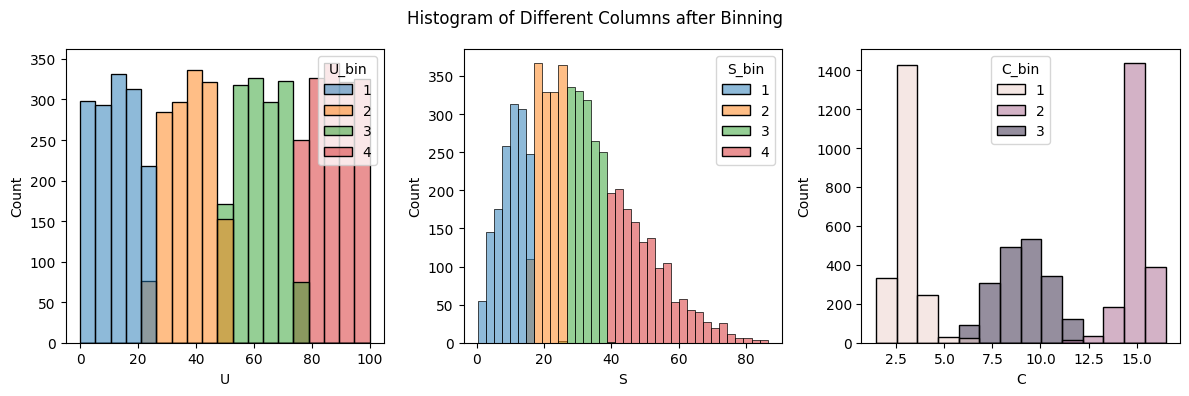

In [10]:
plt.figure(figsize=(12, 4))

columns = [col for col in data.columns if not col.endswith('_bin')]

for idx, col in enumerate(columns):
    plt.subplot(1, len(columns), idx+1)
    sns.histplot(data=data, x=col, hue=f'{col}_bin')
    plt.xlabel(f'{col}')
    plt.ylabel('Count')
plt.suptitle('Histogram of Different Columns after Binning')
plt.tight_layout()
plt.show()

In [55]:
n_samples = 10000

data = pd.DataFrame({
    'Income' : np.random.lognormal(mean=3, sigma=1, size=n_samples)
})

data['Income'].describe()

count    10000.000000
mean        33.119440
std         40.897383
min          0.277506
25%         10.230532
50%         20.438770
75%         40.066442
max        627.094515
Name: Income, dtype: float64

In [56]:
def assign_category(h):
    if h <= 33:
        return 'L'
    elif h <= 40:
        return 'M'
    return 'H'

noise = 2 * np.random.randn(len(data))
data['Hidden'] = data['Income'] + noise
data['Type'] = data['Hidden'].apply(assign_category)

data.drop('Hidden', axis=1, inplace=True)
data.head()

,Income,Type
0,11.766569,L
1,27.584037,L
2,23.112907,L
3,42.711999,H
4,76.919628,H


In [57]:
from sklearn.tree import DecisionTreeClassifier

X = data['Income'].values.reshape(-1, 1)
y = data['Type'].values.reshape(-1, 1)

model = DecisionTreeClassifier(max_leaf_nodes=data['Type'].nunique())
model.fit(X, y)

thresholds = sorted([t for t in model.tree_.threshold if t != -2]) # -2 represents leaf
thresholds = [-np.inf] + thresholds + [np.inf]
data['Income_bin'] = pd.cut(data['Income'], bins=thresholds, labels=[str(x) for x in np.arange(1, data['Type'].nunique()+1)])
data.head()

,Income,Type,Income_bin
0,11.766569,L,1
1,27.584037,L,1
2,23.112907,L,1
3,42.711999,H,3
4,76.919628,H,3


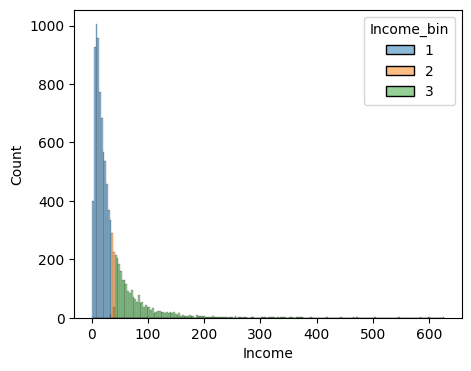

In [58]:
plt.figure(figsize=(5, 4))

sns.histplot(data=data, x='Income', hue='Income_bin')
plt.xlabel('Income')
plt.ylabel('Count')
plt.show()